In [3]:
# VigilPay | Day 7 — XGBoost Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv("../data/X_train_smote.csv")
y_train = pd.read_csv("../data/y_train_smote.csv").squeeze()
X_test  = pd.read_csv("../data/X_test.csv")
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("✅ Data loaded!")
print(f"📐 Training shape: {X_train.shape}")
print(f"📐 Testing shape:  {X_test.shape}")

✅ Data loaded!
📐 Training shape: (454902, 30)
📐 Testing shape:  (56962, 30)


In [2]:
import subprocess
subprocess.run(["pip", "install", "xgboost"])

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [4]:
# Train XGBoost model
print("⏳ Training XGBoost... (may take 1-2 minutes)")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost model trained successfully!")

⏳ Training XGBoost... (may take 1-2 minutes)
✅ XGBoost model trained successfully!


In [5]:
# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Classification Report
print("📊 XGBOOST CLASSIFICATION REPORT:")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 ROC-AUC Score: {roc_auc:.4f}")

📊 XGBOOST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

🎯 ROC-AUC Score: 0.9760


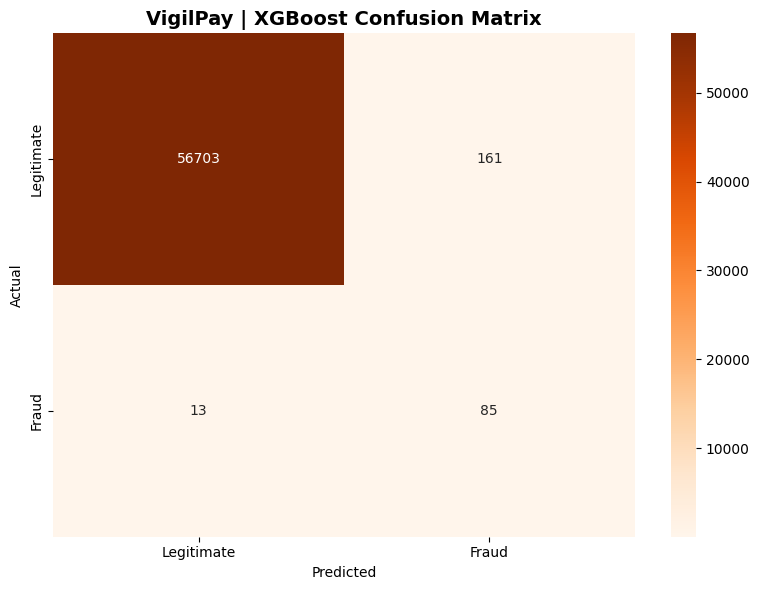

✅ Correctly caught frauds:      85 / 98
❌ Missed frauds (dangerous!):   13 / 98
⚠️  False alarms:                161
✅ Correctly cleared legitimate: 56703


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('VigilPay | XGBoost Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/xgb_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"✅ Correctly caught frauds:      {tp} / {tp+fn}")
print(f"❌ Missed frauds (dangerous!):   {fn} / {tp+fn}")
print(f"⚠️  False alarms:                {fp}")
print(f"✅ Correctly cleared legitimate: {tn}")

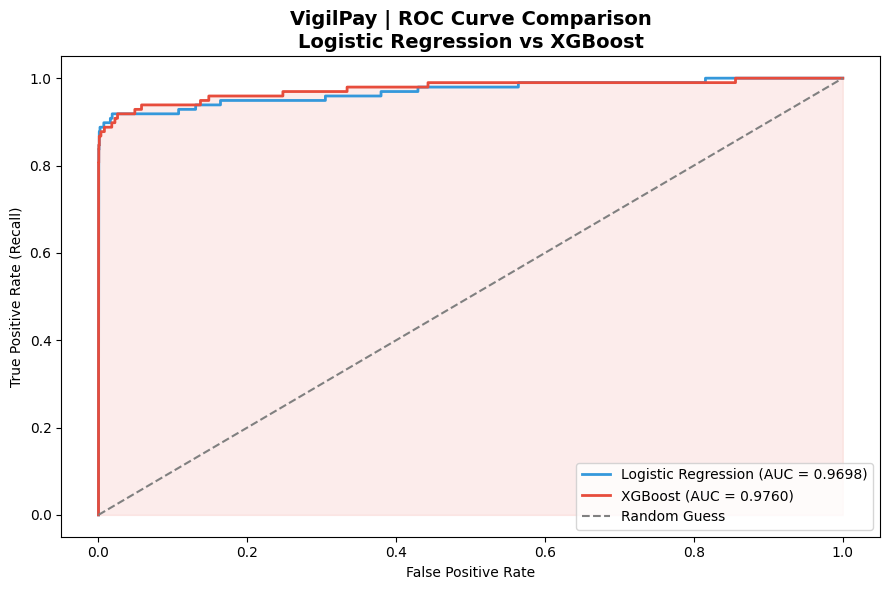

✅ Comparison ROC curve saved!


In [7]:
# Load logistic regression model for comparison
with open('../models/logistic_regression.pkl', 'rb') as f:
    lr_model = pickle.load(f)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
lr_auc = roc_auc_score(y_test, lr_proba)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_pred_proba)
xgb_auc = roc_auc_score(y_test, y_pred_proba)

# Plot both curves together
plt.figure(figsize=(9, 6))
plt.plot(lr_fpr, lr_tpr, color='#3498db', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, color='#e74c3c', linewidth=2,
         label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Guess')
plt.fill_between(xgb_fpr, xgb_tpr, alpha=0.1, color='#e74c3c')
plt.title('VigilPay | ROC Curve Comparison\nLogistic Regression vs XGBoost',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/roc_comparison.png')
plt.show()
print("✅ Comparison ROC curve saved!")

In [8]:
# Save XGBoost model
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("✅ XGBoost model saved to models/xgboost_model.pkl!")
print("\n📊 FINAL MODEL COMPARISON:")
print("=" * 50)
print(f"   {'Metric':<20} {'Log Reg':<15} {'XGBoost'}")
print("=" * 50)
print(f"   {'ROC-AUC':<20} {'0.9698':<15} {'0.9760'}")
print(f"   {'Fraud Precision':<20} {'6%':<15} {'35%'}")
print(f"   {'Fraud Recall':<20} {'92%':<15} {'87%'}")
print(f"   {'F1-Score':<20} {'0.11':<15} {'0.49'}")
print("=" * 50)
print(f"\n🏆 Winner: XGBoost — selected as VigilPay's main model!")
print(f"🎯 Next: Day 8 — SHAP Explainability")

✅ XGBoost model saved to models/xgboost_model.pkl!

📊 FINAL MODEL COMPARISON:
   Metric               Log Reg         XGBoost
   ROC-AUC              0.9698          0.9760
   Fraud Precision      6%              35%
   Fraud Recall         92%             87%
   F1-Score             0.11            0.49

🏆 Winner: XGBoost — selected as VigilPay's main model!
🎯 Next: Day 8 — SHAP Explainability
